# Wektoryzacja danych


In [65]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

## Wczytywanie danych


In [66]:
base_path = Path("..") / "data"
data_path = base_path / "data_processed.csv"

In [67]:
spam_df = pd.read_csv(data_path)

spam_df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Sprawdzenie rozkładu kłas


In [68]:
spam_df["label"].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

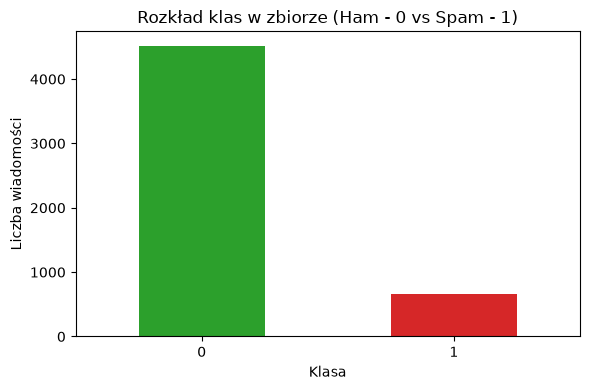

In [69]:
plt.figure(figsize=(6, 4))
spam_df["label"].value_counts().plot(kind="bar", color=["#2ca02c", "#d62728"])
plt.title("Rozkład klas w zbiorze (Ham - 0 vs Spam - 1)")
plt.xlabel("Klasa")
plt.ylabel("Liczba wiadomości")
plt.xticks(rotation=0)
plt.tight_layout()

> W zbiorze znajduje się znacznie więcej wiadomości `ham` niż `spam`. Klasa `ham` stanowi większość danych, dlatego zbiór jest niezbalansowany.

## Podział danych

In [70]:
X = spam_df["text"]
y = spam_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

## Testowanie różnych konfiguracji

In [71]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    lowercase=True,
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 3000)
(1034, 3000)


> Na potrzeby dalszych etapów przyjmujemy konfigurację TF-IDF z maksymalnie 3000 cech, zamianą tekstu na małe litery oraz usunięciem angielskich stop words. Jest to konfiguracja bazowa, która zostanie zweryfikowana podczas trenowania modeli.

## Zapis wektoryzatora i danych

In [72]:
vectorizer_path = base_path / "vectorized"

joblib.dump(vectorizer, vectorizer_path / "tfidf_vectorizer.pkl")
joblib.dump(
    (X_train_tfidf, X_test_tfidf, y_train, y_test),
    vectorizer_path / "tfidf_splits.pkl",
)

['..\\data\\vectorized\\tfidf_splits.pkl']

## Weryfikacja zapisanych danych

In [73]:
def test_pkl_files():
    vectorizer: TfidfVectorizer = joblib.load(vectorizer_path / "tfidf_vectorizer.pkl")
    
    print("---Weryfikacja TF-IDF---")
    print(f"Typ obiektu: {type(vectorizer)}")
    print(f"Rozmiar słownika: {len(vectorizer.vocabulary_)}\n")

    X_train, X_test, y_train, y_test = joblib.load(
        vectorizer_path / "tfidf_splits.pkl")
    
    print("Weryfikacja Danych")
    print(f"x_train (wiadomości treningowe): {X_train.shape}")
    print(f"y_train (etykiety treningowe): {y_train.shape}")
    print(f"x_test (wiadomości testowe): {X_test.shape}")
    print(f"y_test (etykiety testowe): {y_test.shape}\n")

    if X_train.shape[0] == y_train.shape[0] and X_test.shape[0] == y_test.shape[0]:
        print("Liczba wierszy w macierzach x i y zgadza się")
    else:
        print("Liczba wierszy w macierzach X i y nie zgadza się")

test_pkl_files()

---Weryfikacja TF-IDF---
Typ obiektu: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Rozmiar słownika: 3000

Weryfikacja Danych
x_train (wiadomości treningowe): (4135, 3000)
y_train (etykiety treningowe): (4135,)
x_test (wiadomości testowe): (1034, 3000)
y_test (etykiety testowe): (1034,)

Liczba wierszy w macierzach x i y zgadza się


> Sprawdziliśmy poprawność zapisu danych i wektoryzatora. Wszystko się zgadza.


## Podsumowanie

> Dane zostały podzielone na zbiór treningowy i testowy, a następnie przekształcone za pomocą TF-IDF. Zastosowana konfiguracja bazowa wykorzystuje maksymalnie 3000 cech, zamianę liter na małe oraz usunięcie angielskich stop words. Przygotowane dane zostały zapisane i będą wykorzystane w kolejnym etapie do trenowania modeli klasyfikacyjnych.